In [2]:
import numpy as np
import ee
import geemap

ee.Authenticate()
ee.Initialize()

In [3]:
map = geemap.Map()
map.add_basemap("HYBRID")
center = ee.Geometry.Point([46.439209, 30.949347])
map.centerObject(center, 4)

map

Map(center=[30.949347000000003, 46.439209], controls=(WidgetControl(options=['position', 'transparent_bg'], po…

In [4]:
roi = map.draw_last_feature.geometry()
#print("ROI geometry:", roi)

In [5]:
# Creating a timelist
time_start = ee.Date('2005')
time_end = ee.Date('2010')
time_dif = time_end.difference(time_start, 'year').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'year')
)

# Function for obtaining the date for the spicfic time
def annual(date, col):
  start_date = ee.Date(date)
  end_date = start_date.advance(1, 'year')
  img_sum = col.filterDate(start_date, end_date).sum()
  return img_sum.set('system:time_start', start_date.millis())

In [6]:
vis_params4 =  {'bands': ['NDVI'], 'min': -7970.3, 'max': 87319.55, 'palette': ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']}

In [7]:
# Script in the cell is Demo
ndvi = (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .filterDate(time_start, time_end)
    .select("NDVI")
    .map(lambda x: x.multiply(0.0001).copyProperties(x, ['system:time_start'])
    )
)

ndvi_annual = ee.ImageCollection(time_list.map(lambda x: annual(date=x, col=ndvi)))

In [8]:
map.addLayer(ndvi.select(['NDVI']).mean().clip(roi), vis_params4, "NDVI")

In [9]:
# Add one NDVI layer for each year (toggle in the layer manager)
annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

for i in range(5):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    map.addLayer(
        annual_img.clip(roi),
        {'bands': ['NDVI'], 'min': -7970.3, 'max': 87319.55, 'palette': ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']},
        f'NDVI {year_label}',
        False
    )

map

Map(bottom=13847.0, center=[29.735762444449076, 46.65893554687501], controls=(WidgetControl(options=['position…

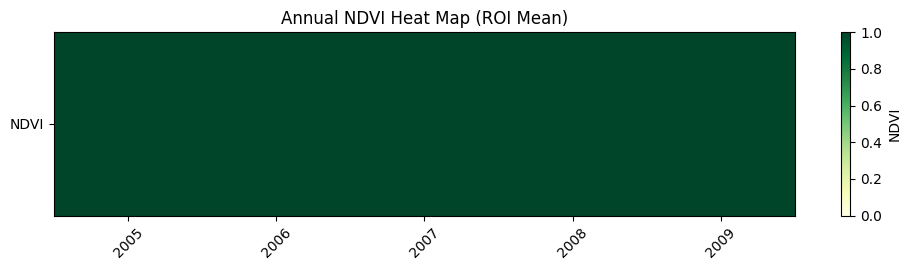

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Plot all yearly NDVI values in one heat map (ROI mean per year)
annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
mean_ndvi = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    ndvi_value = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=1000,
        maxPixels=1e13
    ).get('NDVI').getInfo()

    if ndvi_value is not None:
        years.append(int(year_label))
        mean_ndvi.append(ndvi_value)

heat = np.array(mean_ndvi, dtype=float).reshape(1, -1)

plt.figure(figsize=(max(10, len(years) * 0.6), 2.8))
im = plt.imshow(heat, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
plt.yticks([0], ['NDVI'])
plt.xticks(range(len(years)), years, rotation=45)
plt.title('Annual NDVI Heat Map (ROI Mean)')
cbar = plt.colorbar(im)
cbar.set_label('NDVI')
plt.tight_layout()
plt.show()

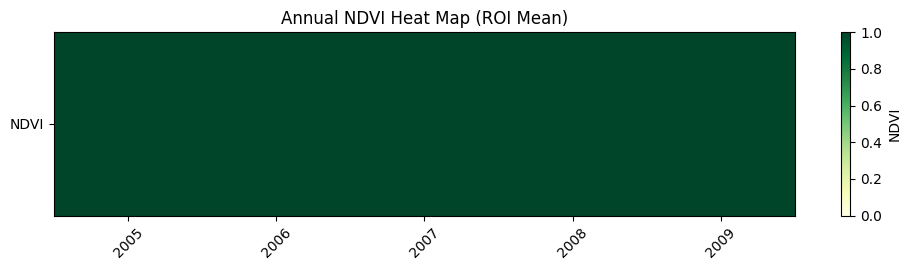

In [11]:
# NDVI HEATMAP (all years in one plot)
import numpy as np
import matplotlib.pyplot as plt

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()
years = []
mean_ndvi = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    ndvi_value = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=1000,
        maxPixels=1e13
    ).get('NDVI').getInfo()
    if ndvi_value is not None:
        years.append(int(year_label))
        mean_ndvi.append(ndvi_value)

heat = np.array(mean_ndvi, dtype=float).reshape(1, -1)
plt.figure(figsize=(max(10, len(years) * 0.6), 2.8))
im = plt.imshow(heat, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
plt.yticks([0], ['NDVI'])
plt.xticks(range(len(years)), years, rotation=45)
plt.title('Annual NDVI Heat Map (ROI Mean)')
cbar = plt.colorbar(im)
cbar.set_label('NDVI')
plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.


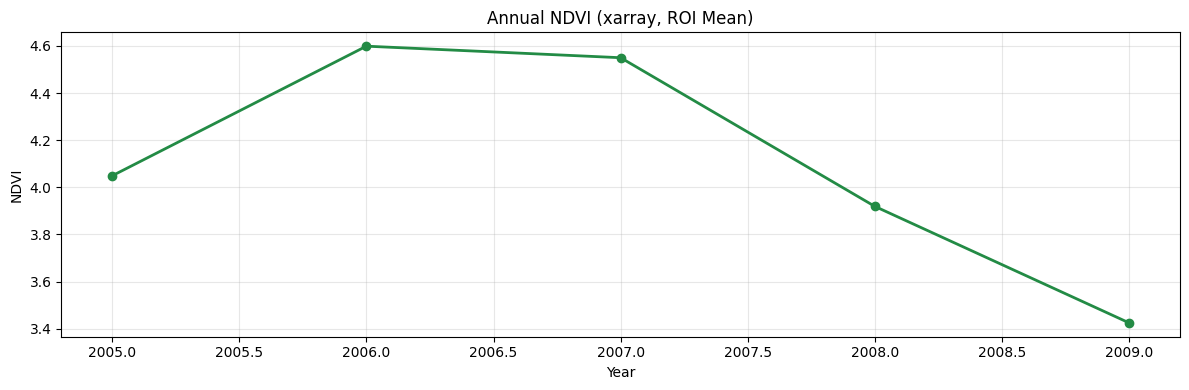

<xarray.DataArray 'NDVI' (year: 5)> Size: 40B
array([4.04893696, 4.59900327, 4.54999704, 3.919035  , 3.42479402])
Coordinates:
  * year     (year) int64 40B 2005 2006 2007 2008 2009

In [12]:
%pip install xarray
# Convert annual NDVI to xarray and plot all years in one figure
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
mean_ndvi = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i))
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    ndvi_value = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=1000,
        maxPixels=1e13
    ).get('NDVI').getInfo()

    if ndvi_value is not None:
        years.append(int(year_label))
        mean_ndvi.append(float(ndvi_value))

ndvi_xr = xr.DataArray(
    data=np.array(mean_ndvi, dtype=float),
    coords={'year': np.array(years, dtype=int)},
    dims=['year'],
    name='NDVI'
)

fig, ax = plt.subplots(figsize=(12, 4))
ndvi_xr.plot(ax=ax, marker='o', linewidth=2, color='#238b45')
ax.set_title('Annual NDVI (xarray, ROI Mean)')
ax.set_xlabel('Year')
ax.set_ylabel('NDVI')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ndvi_xr

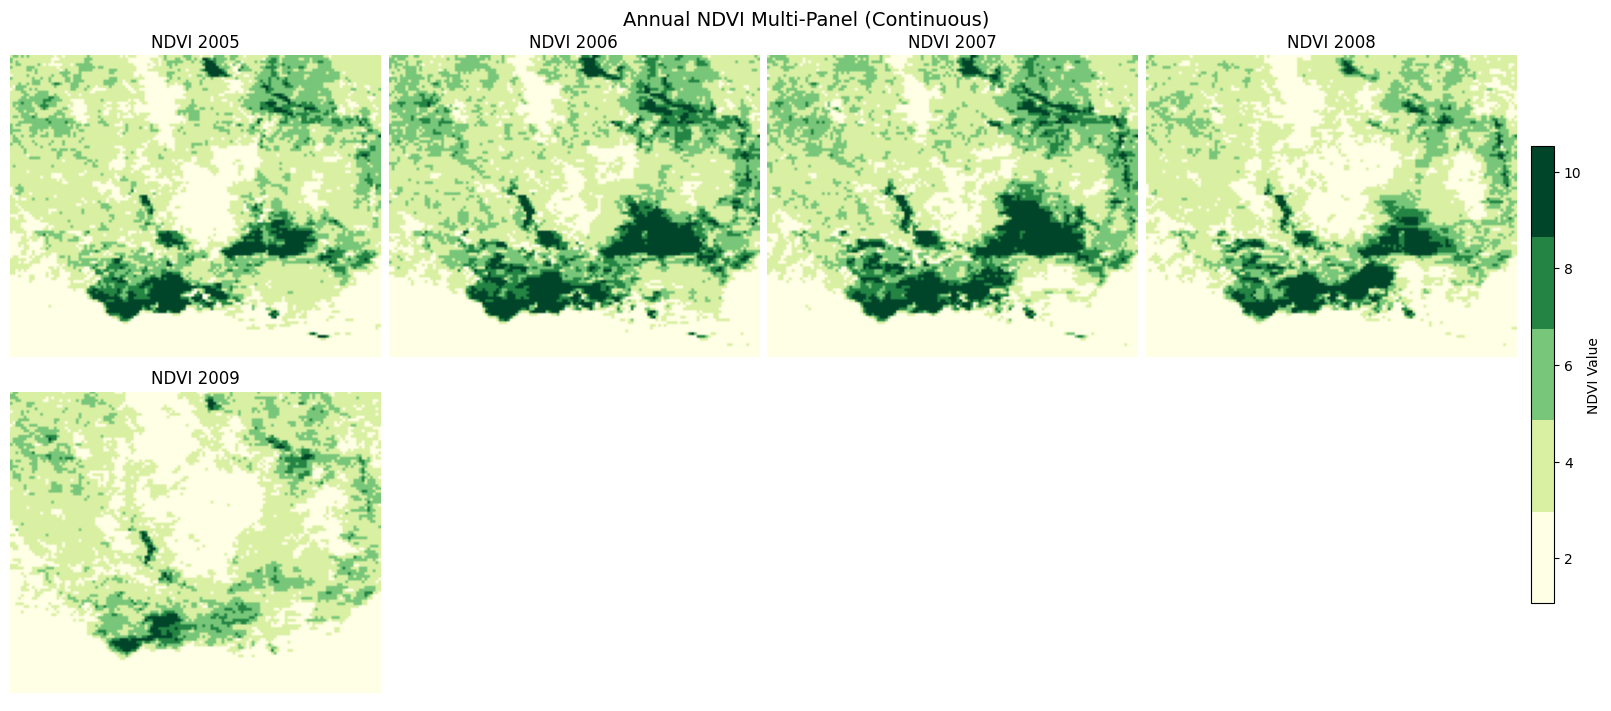

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors


annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
arrays = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i)).clip(roi)
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    arr = geemap.ee_to_numpy(annual_img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    years.append(year_label)
    arrays.append(arr)

if not arrays:
    raise ValueError('No NDVI images were converted to arrays. Check ROI and scale.')

n = len(arrays)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

# Define the color palette and min/max values from your specified vis_params
# vis_params = {'bands': ['NDVI'], 'palette': ['#ffffe5', '#d9f0a3', '#78c679', '#238443', '#004529'], 'min': 1.0750700000000002, 'max': 10.533110000000002}
palette = ['#ffffe5', '#d9f0a3', '#78c679', '#238443', '#004529']
cmap_continuous = matplotlib.colors.ListedColormap(palette)
vmin_val = 1.0750700000000002
vmax_val = 10.533110000000002

for idx, (year_label, arr) in enumerate(zip(years, arrays)):
    # Plot the continuous NDVI array directly without classification
    im = axes[idx].imshow(arr, cmap=cmap_continuous, vmin=vmin_val, vmax=vmax_val)
    axes[idx].set_title(f'NDVI {year_label}')
    axes[idx].axis('off')

for idx in range(n, len(axes)):
    axes[idx].axis('off')

# Create a colorbar for the continuous NDVI values
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.7, pad=0.01)
cbar.set_label('NDVI Value')
fig.suptitle('Annual NDVI Multi-Panel (Continuous)', fontsize=14)
plt.show()

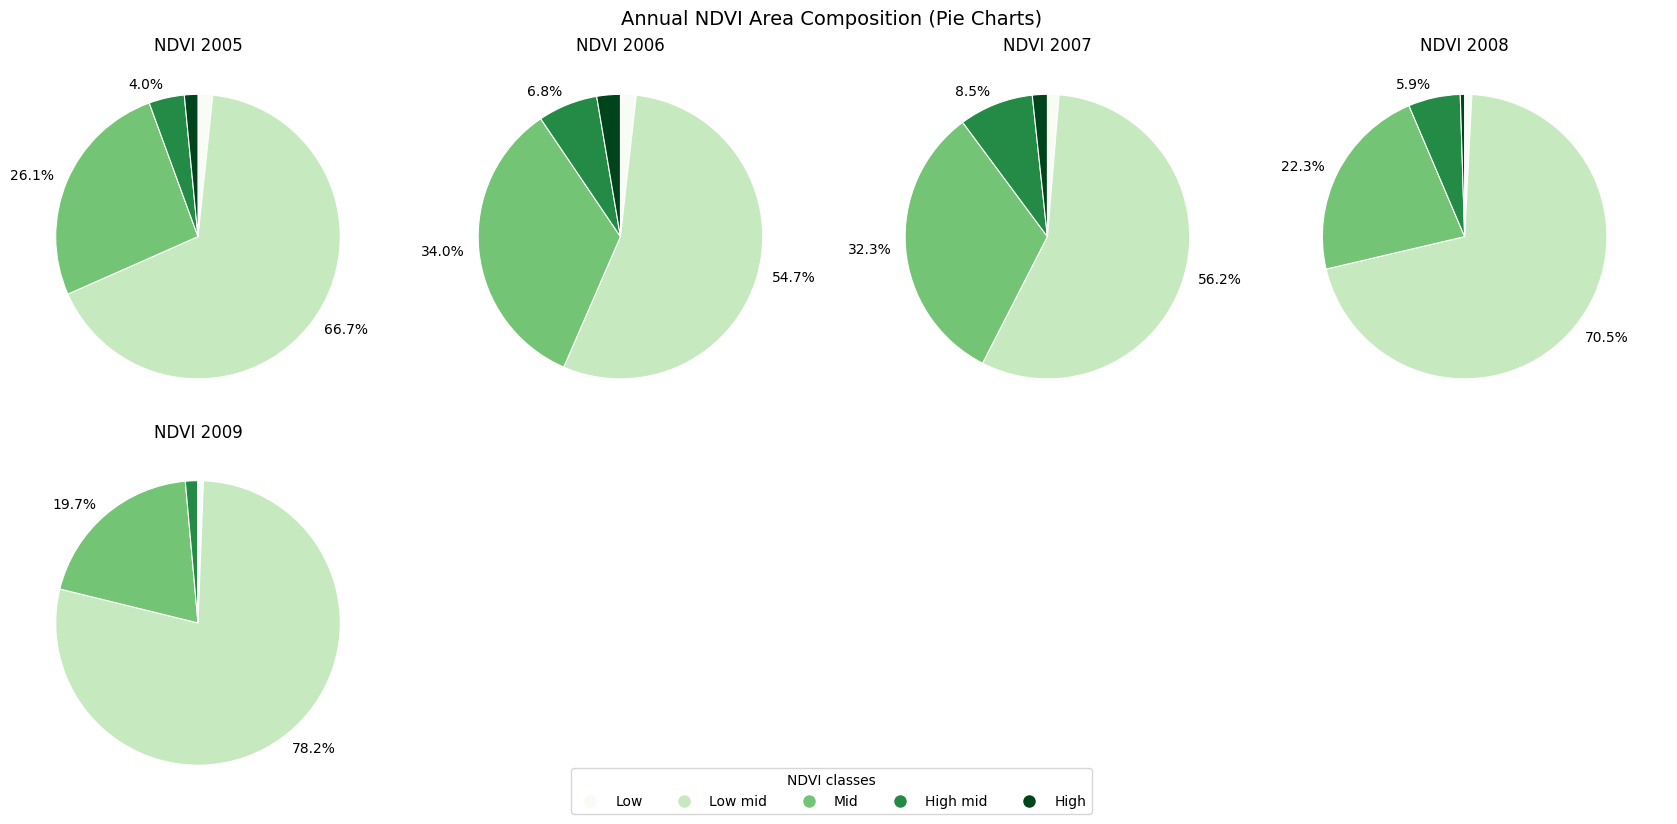

In [14]:
# Multi-panel pie chart: NDVI class area percentage per year
import math
import numpy as np
import matplotlib.pyplot as plt

palette = ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']
n_classes = len(palette)

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
arrays = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i)).clip(roi)
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    arr = geemap.ee_to_numpy(annual_img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    arr = np.array(arr, dtype=float)
    valid = arr[np.isfinite(arr)]
    if valid.size == 0:
        continue
    years.append(year_label)
    arrays.append(valid)

if not arrays:
    raise ValueError('No NDVI data available for pie plotting. Check ROI and scale.')

# Use common class breaks across all years for fair comparison
all_values = np.concatenate(arrays)
global_min = float(np.nanmin(all_values))
global_max = float(np.nanmax(all_values))
if global_min == global_max:
    global_max = global_min + 1e-6
bin_edges = np.linspace(global_min, global_max, n_classes + 1)

n = len(years)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for idx, (year_label, vals) in enumerate(zip(years, arrays)):
    counts, _ = np.histogram(vals, bins=bin_edges)
    total = counts.sum()
    if total == 0:
        axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[idx].set_title(f'NDVI {year_label}')
        axes[idx].axis('off')
        continue
    pct = (counts / total) * 100.0
    labels = [f'{p:.1f}%' if p >= 3 else '' for p in pct]
    axes[idx].pie(
        pct,
        colors=palette,
        labels=labels,
        startangle=90,
        counterclock=False,
        wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'}
    )
    axes[idx].set_title(f'NDVI {year_label}')

for idx in range(n, len(axes)):
    axes[idx].axis('off')

class_names = ['Low', 'Low mid', 'Mid', 'High mid', 'High']
legend_labels = class_names[:n_classes]
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette[i], markersize=10) for i in range(n_classes)]
fig.legend(handles, legend_labels, title='NDVI classes', loc='lower center', ncol=min(n_classes, 5), bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Annual NDVI Area Composition (Pie Charts)', fontsize=14)
plt.show()

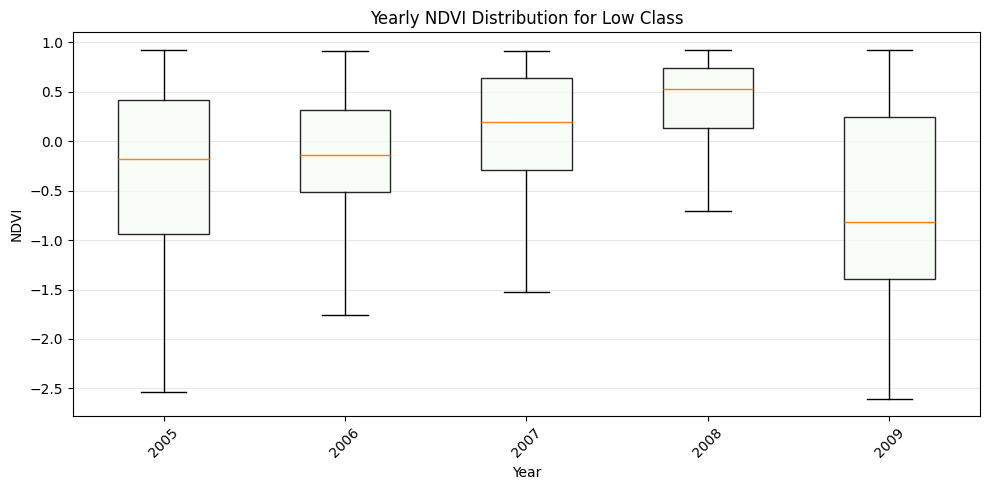

In [15]:
# Boxplot: yearly distribution for the low NDVI class
import numpy as np
import matplotlib.pyplot as plt

palette = ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']
n_classes = len(palette)

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
arrays = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i)).clip(roi)
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    arr = geemap.ee_to_numpy(annual_img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    arr = np.array(arr, dtype=float)
    valid = arr[np.isfinite(arr)]
    if valid.size == 0:
        continue
    years.append(year_label)
    arrays.append(valid)

if not arrays:
    raise ValueError('No NDVI data found. Check ROI and scale.')

# Build class boundaries globally, then keep only the lowest class per year
all_values = np.concatenate(arrays)
global_min = float(np.nanmin(all_values))
global_max = float(np.nanmax(all_values))
if global_min == global_max:
    global_max = global_min + 1e-6
bin_edges = np.linspace(global_min, global_max, n_classes + 1)
low_min = bin_edges[0]
low_max = bin_edges[1]

low_class_yearly = []
low_year_labels = []
for year_label, vals in zip(years, arrays):
    low_vals = vals[(vals >= low_min) & (vals < low_max)]
    if low_vals.size > 0:
        low_class_yearly.append(low_vals)
        low_year_labels.append(year_label)

if not low_class_yearly:
    raise ValueError('No low-class NDVI pixels found with current class boundaries.')

fig, ax = plt.subplots(figsize=(max(10, len(low_year_labels) * 0.6), 5))
bp = ax.boxplot(low_class_yearly, patch_artist=True, labels=low_year_labels, showfliers=False)

for box in bp["boxes"]:
    box.set_facecolor(palette[0])
    box.set_alpha(0.85)

ax.set_title('Yearly NDVI Distribution for Low Class')
ax.set_xlabel('Year')
ax.set_ylabel('NDVI')
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

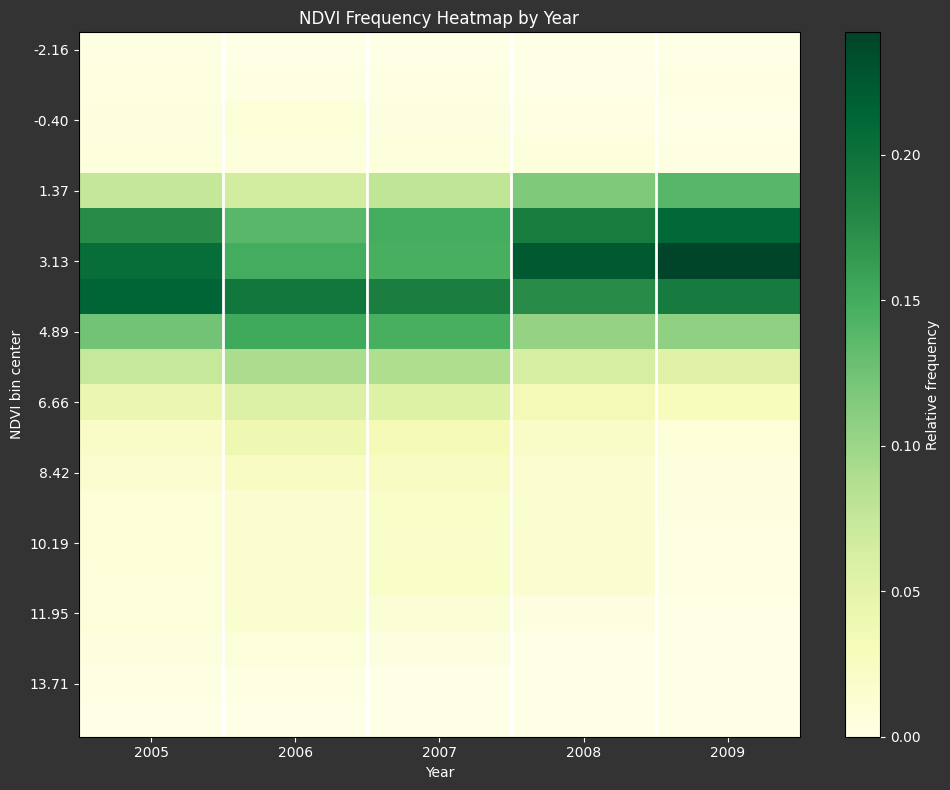

In [18]:
# YEARLY NDVI FREQUENCY HEATMAP (YlGn) - V3
import numpy as np
import matplotlib.pyplot as plt

annual_list = ndvi_annual.toList(ndvi_annual.size())
annual_count = ndvi_annual.size().getInfo()

years = []
arrays = []

for i in range(annual_count):
    annual_img = ee.Image(annual_list.get(i)).clip(roi)
    year_label = ee.Date(annual_img.get('system:time_start')).format('YYYY').getInfo()
    arr = geemap.ee_to_numpy(annual_img, region=roi, scale=1000)
    if arr is None:
        continue
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    vals = np.array(arr, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        continue
    years.append(int(year_label))
    arrays.append(vals)

if not arrays:
    raise ValueError('No NDVI data available. Check ROI and scale.')

all_vals = np.concatenate(arrays)
vmin = float(np.nanmin(all_vals))
vmax = float(np.nanmax(all_vals))
if vmin == vmax:
    vmax = vmin + 1e-6
n_bins = 20
bin_edges = np.linspace(vmin, vmax, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

freq_matrix = []
for vals in arrays:
    counts, _ = np.histogram(vals, bins=bin_edges)
    freq = counts / counts.sum() if counts.sum() > 0 else counts
    freq_matrix.append(freq)
freq_matrix = np.array(freq_matrix, dtype=float)

fig, ax = plt.subplots(figsize=(max(10, len(years) * 0.6), 8))
im = ax.imshow(freq_matrix.T, aspect='auto', cmap='YlGn')
ax.set_title('NDVI Frequency Heatmap by Year')
ax.set_xlabel('Year')
ax.set_ylabel('NDVI bin center')

ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years)

ytick_idx = np.arange(0, n_bins, max(1, n_bins // 8))
ax.set_yticks(ytick_idx)
ax.set_yticklabels([f"{bin_centers[i]:.2f}" for i in ytick_idx])

# Add vertical lines to separate columns (years)
ax.vlines(np.arange(0.5, len(years)-0.5, 1), ymin=-0.5, ymax=n_bins-0.5, colors='white', linewidth=2)

# Set dark background
ax.set_facecolor('#333333')
fig.patch.set_facecolor('#333333')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Relative frequency')
cbar.ax.tick_params(colors='white')
cbar.ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.show()